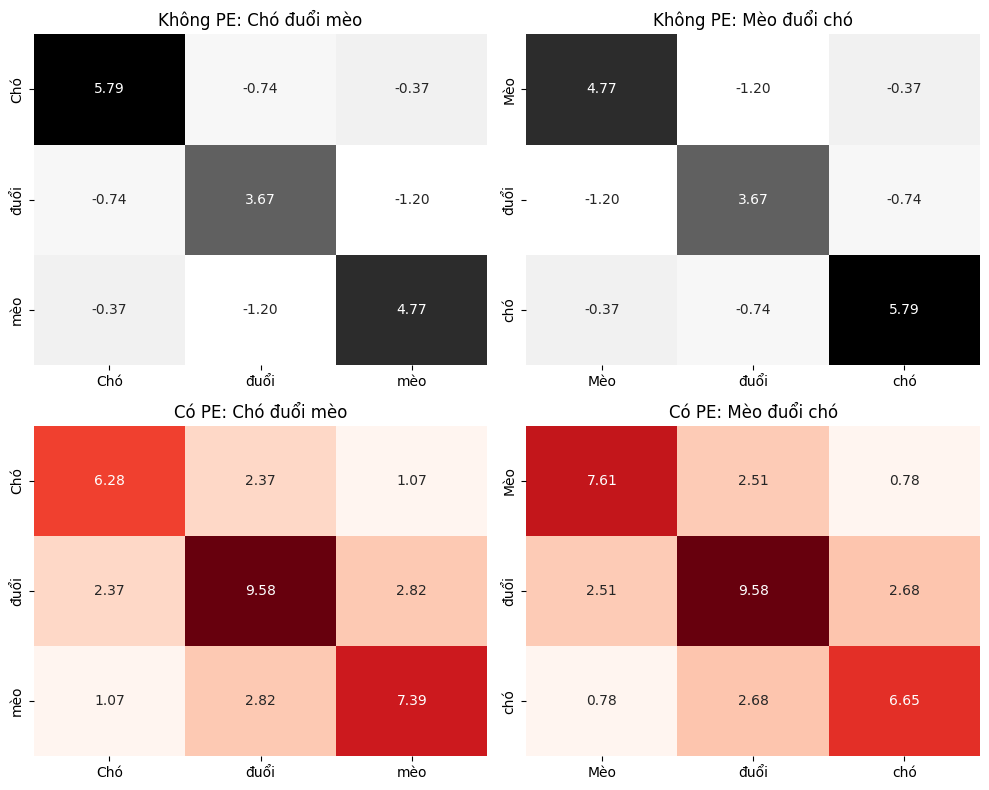

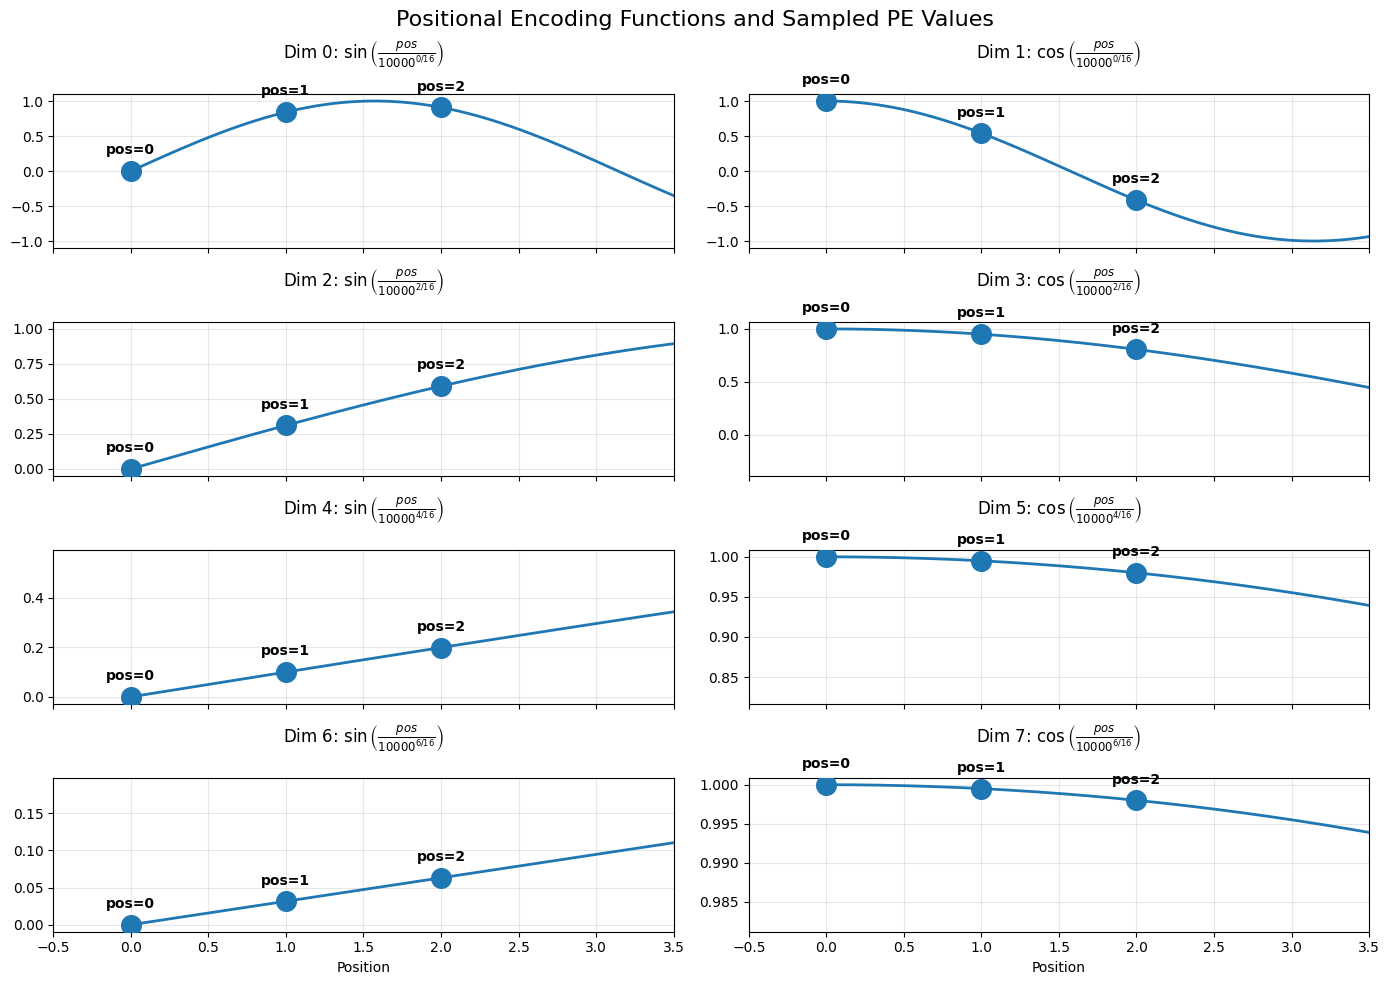

In [16]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

torch.manual_seed(42)

vocab = {"chó": 0, "đuổi": 1, "mèo": 2}
d_model = 16
seq_len = 3
s1_words = ["Chó", "đuổi", "mèo"]
s2_words = ["Mèo", "đuổi", "chó"]
s1_idx = torch.tensor([vocab["chó"], vocab["đuổi"], vocab["mèo"]])
s2_idx = torch.tensor([vocab["mèo"], vocab["đuổi"], vocab["chó"]])

emb_layer = nn.Embedding(num_embeddings=len(vocab), embedding_dim=d_model)

emb1 = emb_layer(s1_idx)
emb2 = emb_layer(s2_idx)

pe_matrix = torch.zeros(seq_len, d_model)
position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)
div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
angles = position * div_term
pe_matrix[:, 0::2] = torch.sin(angles)
pe_matrix[:, 1::2] = torch.cos(angles)

final1 = emb1 + pe_matrix
final2 = emb2 + pe_matrix

scale = math.sqrt(d_model)
attn1_no_pe = (emb1 @ emb1.T / scale).detach().numpy()
attn2_no_pe = (emb2 @ emb2.T / scale).detach().numpy()
attn1_with_pe = (final1 @ final1.T / scale).detach().numpy()
attn2_with_pe = (final2 @ final2.T / scale).detach().numpy()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.heatmap(attn1_no_pe, ax=axes[0, 0], annot=True, fmt=".2f", cmap="Greys", 
            xticklabels=s1_words, yticklabels=s1_words, cbar=False)
axes[0, 0].set_title("Không PE: Chó đuổi mèo")

sns.heatmap(attn2_no_pe, ax=axes[0, 1], annot=True, fmt=".2f", cmap="Greys", 
            xticklabels=s2_words, yticklabels=s2_words, cbar=False)
axes[0, 1].set_title("Không PE: Mèo đuổi chó")

sns.heatmap(attn1_with_pe, ax=axes[1, 0], annot=True, fmt=".2f", cmap="Reds", 
            xticklabels=s1_words, yticklabels=s1_words, cbar=False)
axes[1, 0].set_title("Có PE: Chó đuổi mèo")

sns.heatmap(attn2_with_pe, ax=axes[1, 1], annot=True, fmt=".2f", cmap="Reds", 
            xticklabels=s2_words, yticklabels=s2_words, cbar=False)
axes[1, 1].set_title("Có PE: Mèo đuổi chó")

plt.tight_layout()
plt.show()

x = np.linspace(0, 6, 1000)
num_pairs = 4
fig, axes = plt.subplots(
    nrows=num_pairs,
    ncols=2,
    figsize=(14, 10),
    sharex=True
)

positions = np.arange(seq_len)
for i in range(num_pairs):
    scale_i = 10000 ** ((2 * i) / d_model)
    y_sin = np.sin(x / scale_i)
    axes[i, 0].plot(x, y_sin, linewidth=2)

    sin_points = np.sin(positions / scale_i)

    axes[i, 0].scatter(
        positions,
        sin_points,
        s=200,
        zorder=10
    )

    for p, y in zip(positions, sin_points):
        axes[i, 0].annotate(
            f"pos={p}",
            (p, y),
            fontsize=10,
            fontweight="bold",
            textcoords="offset points",
            xytext=(0, 12),
            ha="center"
        )

    axes[i, 0].set_xlim(-0.5, 3.5)

    axes[i, 0].set_title(
        rf"Dim {2*i}: "
        rf"$\sin\left(\frac{{pos}}{{10000^{{{2*i}/{d_model}}}}}\right)$",
        pad=25
    )

    axes[i, 0].grid(alpha=0.3)

    y_cos = np.cos(x / scale_i)

    axes[i, 1].plot(
        x,
        y_cos,
        linewidth=2
    )

    cos_points = np.cos(positions / scale_i)

    axes[i, 1].scatter(
        positions,
        cos_points,
        s=200,
        zorder=10
    )

    for p, y in zip(positions, cos_points):
        axes[i, 1].annotate(
            f"pos={p}",
            (p, y),
            fontsize=10,
            fontweight="bold",
            textcoords="offset points",
            xytext=(0, 12),
            ha="center"
        )
        
    axes[i, 1].set_xlim(-0.5, 3.5)
    
    axes[i, 1].set_title(
        rf"Dim {2*i+1}: "
        rf"$\cos\left(\frac{{pos}}{{10000^{{{2*i}/{d_model}}}}}\right)$",
        pad=25
    )
    
    axes[i, 1].grid(alpha=0.3)

axes[-1, 0].set_xlabel("Position")
axes[-1, 1].set_xlabel("Position")

fig.suptitle(
    "Positional Encoding Functions and Sampled PE Values",
    fontsize=16
)

plt.tight_layout()
plt.show()